# Pinar del Rio

In [1]:
print(1)

1


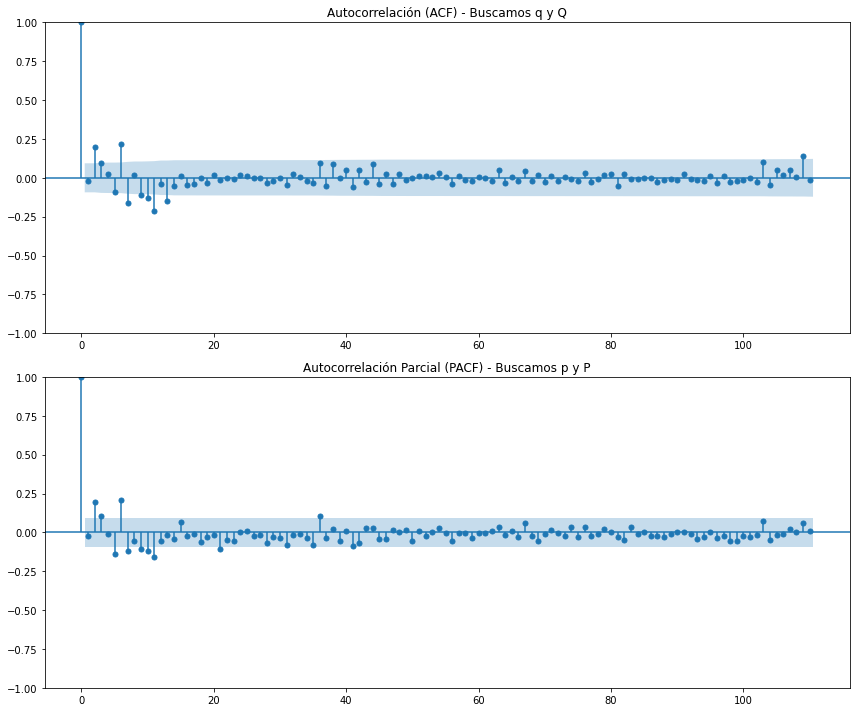

In [1]:
import pandas as pd
import os

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

nombre_provincia = 'Pinar del Río'

carpeta_salida = 'dataframes_con_lags'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df_pinar_del_rio = pd.read_csv(ruta_completa)

# lags=110 para ver claramente lo que pasa en el periodo 52 y 104
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
serie_diferenciada = df_pinar_del_rio["Casos_Dengue"].diff().dropna()
# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [2]:
df_pinar_del_rio= df_pinar_del_rio.drop(['Unnamed: 0', "Provincias"], axis=1)
df_pinar_del_rio.columns

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue',
       'Temperatura med', 'Humedad Relat', 'Precipitaciones', 'Año_y', 'Mes',
       'Temperatura med_lag17'],
      dtype='object')

In [3]:
import itertools
import statsmodels.api as sm

p =  [0,1,2]
q=[0,1,2]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df_pinar_del_rio["Casos_Dengue"]
exog_vars =df_pinar_del_rio[["Temperatura med","Humedad Relat","Precipitaciones","Temperatura med_lag17"]]


n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

mejores_params = None
mejor_aic = float("inf")
variables_exog=df_pinar_del_rio[["Temperatura med","Humedad Relat","Precipitaciones","Temperatura med_lag17"]]

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 4155.446238547832
(0, 1, 0) (0, 0, 1, 52) 3638.8210693725255
(0, 1, 0) (0, 1, 0, 52) 3884.9755668596804
(0, 1, 0) (0, 1, 1, 52) 3259.7159907001205
(0, 1, 0) (1, 0, 0, 52) 3647.3915539478503


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(0, 1, 0) (1, 0, 1, 52) 3640.8054147384564
(0, 1, 0) (1, 1, 0, 52) 3320.7733694282183
(0, 1, 0) (1, 1, 1, 52) 3254.0388165088902
(0, 1, 1) (0, 0, 0, 52) 4147.828776863536
(0, 1, 1) (0, 0, 1, 52) 3631.70485863511
(0, 1, 1) (0, 1, 0, 52) 3876.963013442834
(0, 1, 1) (0, 1, 1, 52) 3252.3057493328142
(0, 1, 1) (1, 0, 0, 52) 3648.741405581077


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(0, 1, 1) (1, 0, 1, 52) 3633.6974684602847
(0, 1, 1) (1, 1, 0, 52) 3320.309597017682
(0, 1, 1) (1, 1, 1, 52) 3246.387123286495
(0, 1, 2) (0, 0, 0, 52) 4120.795141594502
(0, 1, 2) (0, 0, 1, 52) 3603.234717509278
(0, 1, 2) (0, 1, 0, 52) 3847.562904547267
(0, 1, 2) (0, 1, 1, 52) 3225.392111169623
(0, 1, 2) (1, 0, 0, 52) 3628.5342993277336
(0, 1, 2) (1, 0, 1, 52) 3605.1816755916534


...

(2, 1, 2) (1, 0, 1, 52) 3602.178977519648


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (1, 1, 0, 52) 3277.1730111836537


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (1, 1, 1, 52) 3217.965242815864
Mejor SARIMA: ((2, 1, 2), (1, 1, 1, 52)) con AIC: 3217.965242815864


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


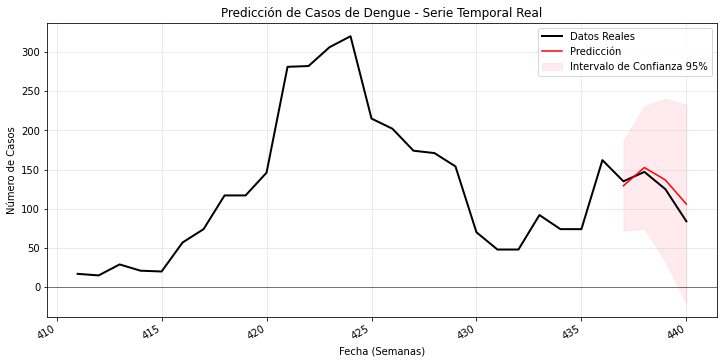

Error Absoluto Medio (MAE): 11.22 casos
Raíz del Error Cuadrático Medio (RMSE): 13.07 casos
Error Porcentual Absoluto Medio (MAPE): 10.88%


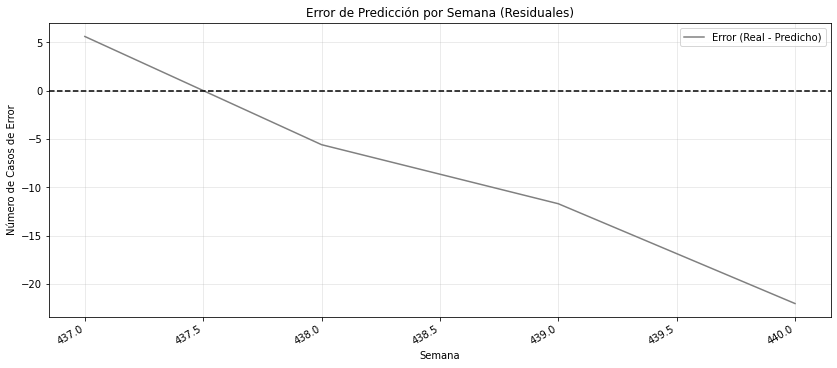

In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

# df_pinar_del_rio['Fecha'] = pd.to_datetime(df_pinar_del_rio['Fecha'])
# df_pinar_del_rio = df_pinar_del_rio.set_index('Fecha')


model_final = SARIMAX(train_y, 
                      exog=train_exog, 
                      order=(2, 1, 2), 
                      seasonal_order=(1, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast, exog=test_exog)
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

In [4]:
df_pinar_del_rio

,Año_x,Semana Estadística,Fecha,Casos_Dengue,Temperatura med,Humedad Relat,Precipitaciones,Año_y,Mes,Temperatura med_lag17
0,2014,18,2014-05-05,0.0,26.150,77.500,36.1625,2014.0,5.0,21.7000
1,2014,19,2014-05-12,0.0,26.275,78.750,36.1625,2014.0,5.0,22.2125
2,2014,20,2014-05-19,33.0,26.400,80.000,36.1625,2014.0,5.0,22.7250
3,2014,21,2014-05-26,0.0,26.525,81.250,36.1625,2014.0,5.0,23.2375
4,2014,22,2014-06-02,0.0,26.650,82.500,37.3900,2014.0,6.0,23.7500
...,...,...,...,...,...,...,...,...,...,...
436,2022,45,2022-11-07,162.0,26.150,80.000,23.5375,2022.0,11.0,27.7375
437,2022,46,2022-11-14,135.0,25.600,79.625,23.5375,2022.0,11.0,27.7750
438,2022,47,2022-11-21,147.0,25.050,79.250,23.5375,2022.0,11.0,27.8125
439,2022,48,2022-11-28,125.0,24.500,78.875,23.5375,2022.0,11.0,27.8500


# Artemisa

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue',
       'Temperatura med', 'Humedad Relat', 'Precipitaciones', 'Año_y', 'Mes',
       'Precipitaciones_lag5'],
      dtype='object')


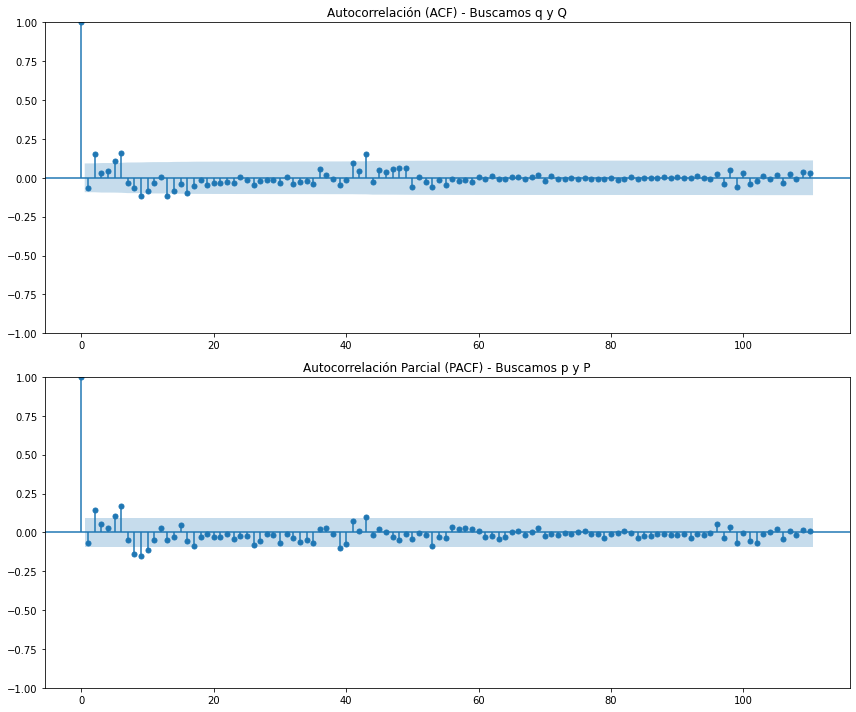

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Artemisa'

carpeta_salida = 'dataframes_con_lags'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df_artemisa = pd.read_csv(ruta_completa)

df_artemisa= df_artemisa.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df_artemisa.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df_artemisa["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [11]:
import itertools
import statsmodels.api as sm

p =  [0,1,2]
q=[0,1,2]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df_artemisa["Casos_Dengue"]
exog_vars =df_artemisa[["Temperatura med","Humedad Relat","Precipitaciones","Precipitaciones_lag5"]]

n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 3373.9810230530647
(0, 1, 0) (0, 0, 1, 52) 3028.598765004487
(0, 1, 0) (0, 1, 0, 52) 3219.9989267032124
(0, 1, 0) (0, 1, 1, 52) 2640.539829945382
(0, 1, 0) (1, 0, 0, 52) 3035.6540831277644
(0, 1, 0) (1, 0, 1, 52) 3026.302335574937
(0, 1, 0) (1, 1, 0, 52) 2691.958139970294
(0, 1, 0) (1, 1, 1, 52) 2671.2676117737574
(0, 1, 1) (0, 0, 0, 52) 3365.549131018977
(0, 1, 1) (0, 0, 1, 52) 3019.7969412938637
(0, 1, 1) (0, 1, 0, 52) 3211.7532561849184
(0, 1, 1) (0, 1, 1, 52) 2635.9846031566485
(0, 1, 1) (1, 0, 0, 52) 3033.4999531395524
(0, 1, 1) (1, 0, 1, 52) 3018.8647132060046
(0, 1, 1) (1, 1, 0, 52) 2693.6670509051255
(0, 1, 1) (1, 1, 1, 52) 2664.4081453889567
(0, 1, 2) (0, 0, 0, 52) 3353.6064452521982
(0, 1, 2) (0, 0, 1, 52) 3009.582031123461
(0, 1, 2) (0, 1, 0, 52) 3192.8387810294803
(0, 1, 2) (0, 1, 1, 52) 2621.6170813900276
(0, 1, 2) (1, 0, 0, 52) 3029.805572126557
(0, 1, 2) (1, 0, 1, 52) 3007.50245350182
(0, 1, 2) (1, 1, 0, 52) 2679.981821286789
(0, 1, 2) (1, 1, 1, 5

/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (0, 0, 0, 52) 3357.6176244169815


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (0, 0, 1, 52) 3013.606187128086
(2, 1, 2) (0, 1, 0, 52) 3192.5690910686035
(2, 1, 2) (0, 1, 1, 52) 2620.30874598275


...

(2, 1, 2) (1, 0, 0, 52) 3020.570462101423


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (1, 0, 1, 52) 3011.3145973694554


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (1, 1, 0, 52) 2660.6190008839512
(2, 1, 2) (1, 1, 1, 52) 2653.266002842951
Mejor SARIMA: ((2, 1, 2), (0, 1, 1, 52)) con AIC: 2620.30874598275


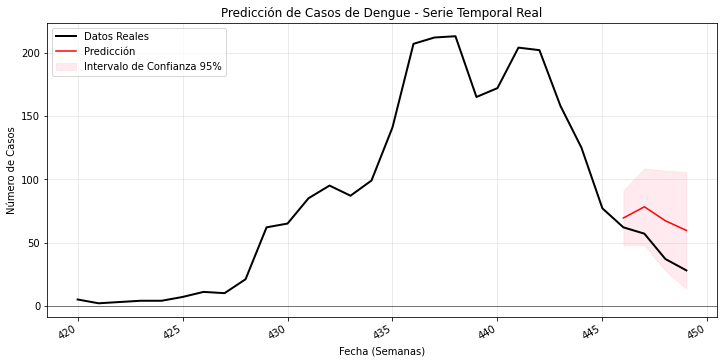

Error Absoluto Medio (MAE): 22.61 casos
Raíz del Error Cuadrático Medio (RMSE): 24.58 casos
Error Porcentual Absoluto Medio (MAPE): 60.92%


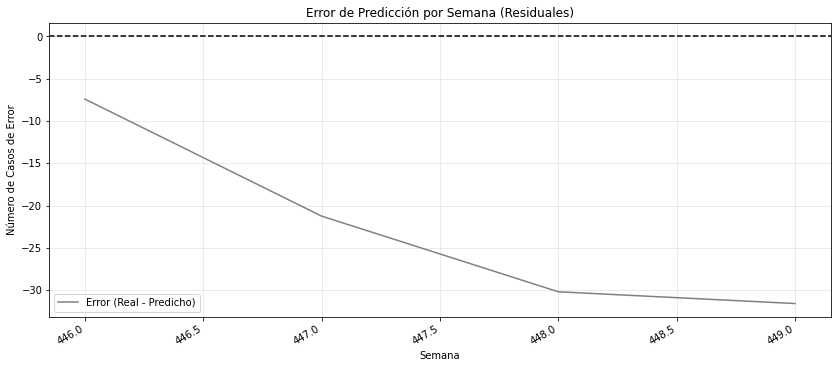

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

# df_pinar_del_rio['Fecha'] = pd.to_datetime(df_pinar_del_rio['Fecha'])
# df_pinar_del_rio = df_pinar_del_rio.set_index('Fecha')


model_final = SARIMAX(train_y, 
                      exog=train_exog, 
                      order=(2, 1, 2), 
                      seasonal_order=(0, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast, exog=test_exog)
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# La Habana

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue',
       'Temperatura med', 'Humedad Relat', 'Precipitaciones', 'Año_y', 'Mes',
       'Temperatura med_lag6'],
      dtype='object')


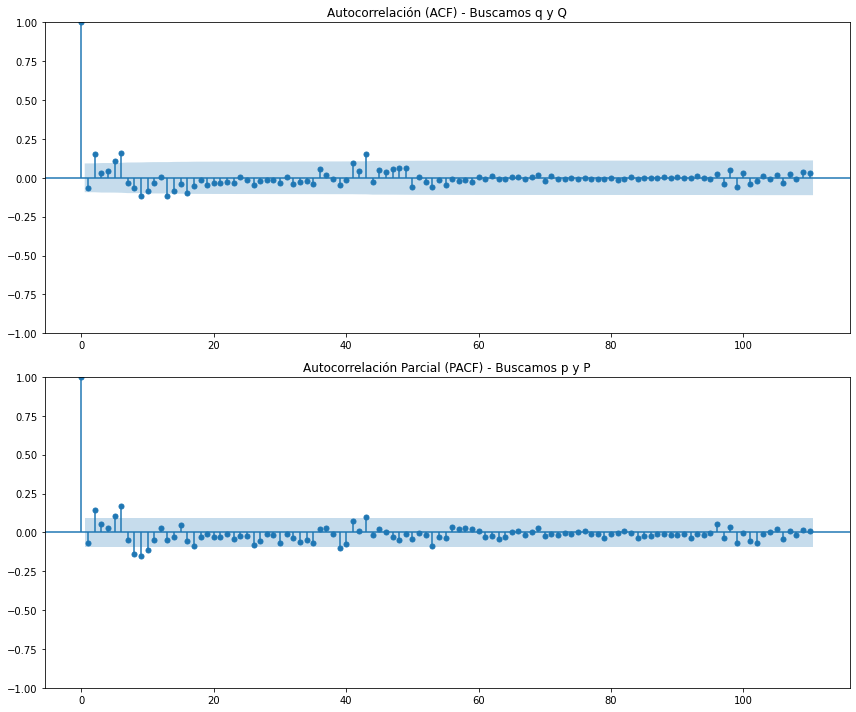

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'La_Habana'

carpeta_salida = 'dataframes_con_lags'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df_artemisa["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [20]:
import itertools
import statsmodels.api as sm

p =  [0,1,2]
q=[0,1,2]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]
exog_vars =df[["Temperatura med","Humedad Relat","Precipitaciones","Temperatura med_lag6"]]

n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 6059.384032158717
(0, 1, 0) (0, 0, 1, 52) 5313.4803489812075
(0, 1, 0) (0, 1, 0, 52) 5586.970488949629
(0, 1, 0) (0, 1, 1, 52) 4573.950635121595
(0, 1, 0) (1, 0, 0, 52) 5322.135092871225
(0, 1, 0) (1, 0, 1, 52) 5287.345386949814
(0, 1, 0) (1, 1, 0, 52) 4604.696270149427


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(0, 1, 0) (1, 1, 1, 52) 4593.799791801736
(0, 1, 1) (0, 0, 0, 52) 6030.964818405195


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(0, 1, 1) (0, 0, 1, 52) 5294.503172516637
(0, 1, 1) (0, 1, 0, 52) 5551.980114438491


...

(2, 1, 2) (1, 0, 1, 52) 5231.461458391389


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (1, 1, 0, 52) 4550.361956331048


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (1, 1, 1, 52) 4587.421064845182
Mejor SARIMA: ((1, 1, 2), (0, 1, 1, 52)) con AIC: 4523.362406760461


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


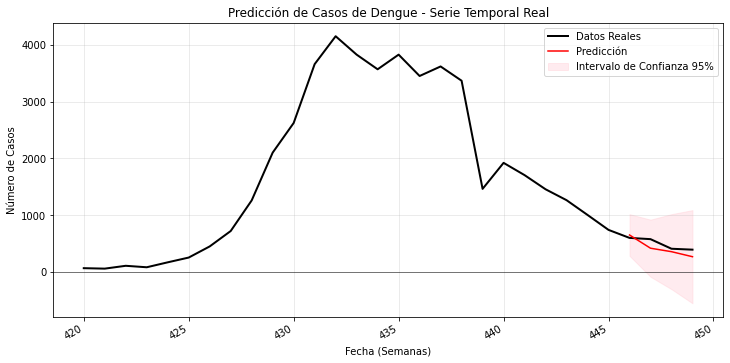

Error Absoluto Medio (MAE): 96.67 casos
Raíz del Error Cuadrático Medio (RMSE): 107.46 casos
Error Porcentual Absoluto Medio (MAPE): 20.01%


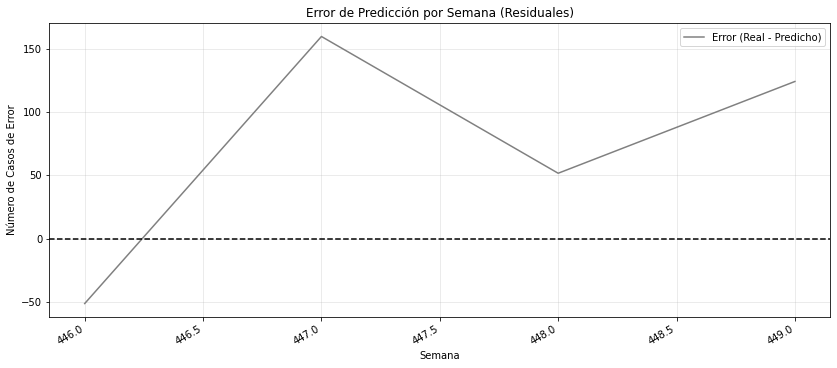

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                      exog=train_exog, 
                      order=(1, 1, 2), 
                      seasonal_order=(0, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast, exog=test_exog)
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Mayabeque

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue',
       'Temperatura med', 'Humedad Relat', 'Precipitaciones', 'Año_y', 'Mes',
       'Precipitaciones_lag5', 'Precipitaciones_lag13'],
      dtype='object')


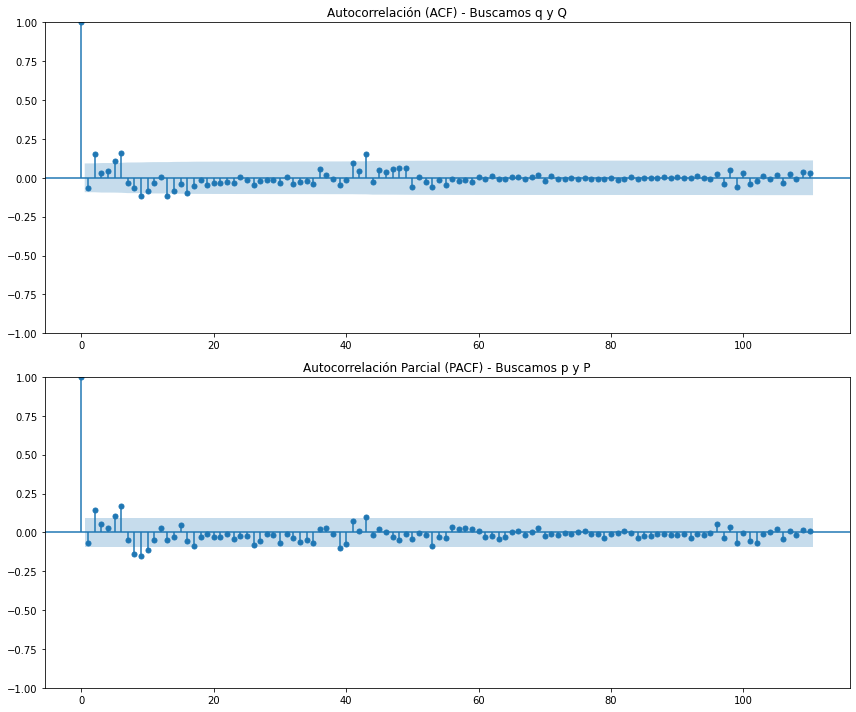

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Mayabeque'

carpeta_salida = 'dataframes_con_lags'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df_artemisa["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [24]:
import itertools
import statsmodels.api as sm

p =  [0,1,2]
q=[0,1,2]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]
exog_vars =df[["Temperatura med","Humedad Relat","Precipitaciones",'Precipitaciones_lag5', 'Precipitaciones_lag13']]

n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 3839.901341211069
(0, 1, 0) (0, 0, 1, 52) 3435.4082966045726
(0, 1, 0) (0, 1, 0, 52) 3485.018862582725
(0, 1, 0) (0, 1, 1, 52) 3032.481248243355
(0, 1, 0) (1, 0, 0, 52) 3442.8702322408003
(0, 1, 0) (1, 0, 1, 52) 3437.030789842293
(0, 1, 0) (1, 1, 0, 52) 3045.8939357156387
(0, 1, 0) (1, 1, 1, 52) 3038.5035957063556
(0, 1, 1) (0, 0, 0, 52) 3827.333509496762
(0, 1, 1) (0, 0, 1, 52) 3423.6407255446015
(0, 1, 1) (0, 1, 0, 52) 3476.2174520685785
(0, 1, 1) (0, 1, 1, 52) 3022.286726422357
(0, 1, 1) (1, 0, 0, 52) 3439.048173855483
(0, 1, 1) (1, 0, 1, 52) 3425.387465817086
(0, 1, 1) (1, 1, 0, 52) 3044.077085499322
(0, 1, 1) (1, 1, 1, 52) 3028.3127582658926
(0, 1, 2) (0, 0, 0, 52) 3742.5275167539626
(0, 1, 2) (0, 0, 1, 52) 3348.2663034383286
(0, 1, 2) (0, 1, 0, 52) 3414.7108058355234
(0, 1, 2) (0, 1, 1, 52) 2961.334690352968
(0, 1, 2) (1, 0, 0, 52) 3371.079561535119
(0, 1, 2) (1, 0, 1, 52) 3349.854930312362
(0, 1, 2) (1, 1, 0, 52) 2993.8250447001938
(0, 1, 2) (1, 1, 1, 52)

/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (0, 0, 1, 52) 3335.2211613125583
(2, 1, 2) (0, 1, 0, 52) 3403.746298846862


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (0, 1, 1, 52) 2947.2737999450655


...

(2, 1, 2) (1, 0, 1, 52) 3336.881182995289


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (1, 1, 0, 52) 2962.1676426125346


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (1, 1, 1, 52) 2953.391962732681
Mejor SARIMA: ((2, 1, 2), (0, 1, 1, 52)) con AIC: 2947.2737999450655


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


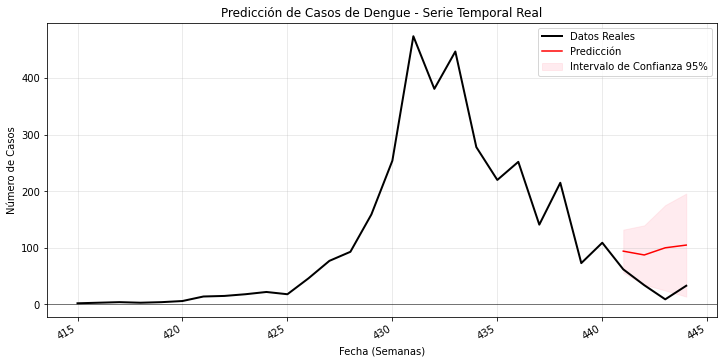

Error Absoluto Medio (MAE): 62.12 casos
Raíz del Error Cuadrático Medio (RMSE): 65.85 casos
Error Porcentual Absoluto Medio (MAPE): 359.67%


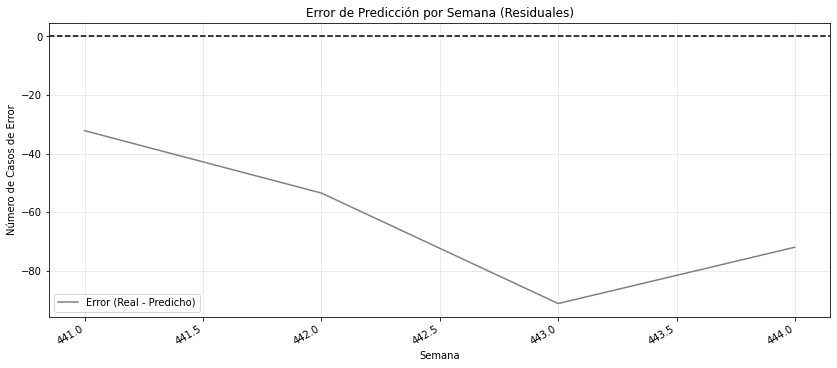

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                      exog=train_exog, 
                      order=(2, 1, 2), 
                      seasonal_order=(0, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast, exog=test_exog)
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Matanzas

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue',
       'Temperatura med', 'Humedad Relat', 'Precipitaciones', 'Año_y', 'Mes',
       'Precipitaciones_lag5', 'Precipitaciones_lag13'],
      dtype='object')


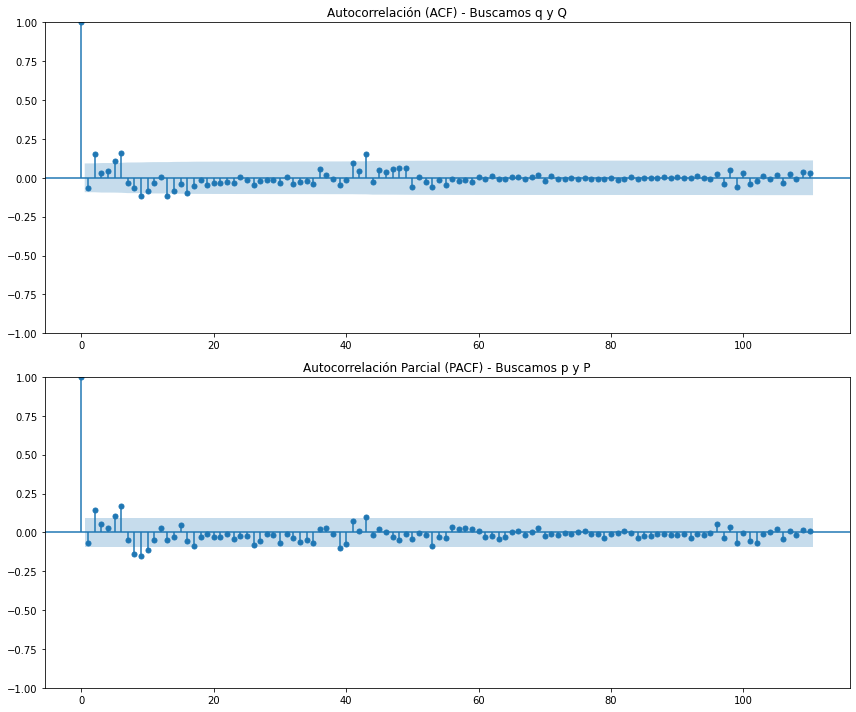

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Mayabeque'

carpeta_salida = 'dataframes_con_lags'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df_artemisa["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [27]:
import itertools
import statsmodels.api as sm

p =  [0,1,2]
q=[0,1,2]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]
exog_vars =df[["Temperatura med","Humedad Relat","Precipitaciones",'Precipitaciones_lag5', 'Precipitaciones_lag13']]

n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 3839.901341211069
(0, 1, 0) (0, 0, 1, 52) 3435.4082966045726
(0, 1, 0) (0, 1, 0, 52) 3485.018862582725
(0, 1, 0) (0, 1, 1, 52) 3032.481248243355
(0, 1, 0) (1, 0, 0, 52) 3442.8702322408003
(0, 1, 0) (1, 0, 1, 52) 3437.030789842293
(0, 1, 0) (1, 1, 0, 52) 3045.8939357156387
(0, 1, 0) (1, 1, 1, 52) 3038.5035957063556
(0, 1, 1) (0, 0, 0, 52) 3827.333509496762
(0, 1, 1) (0, 0, 1, 52) 3423.6407255446015
(0, 1, 1) (0, 1, 0, 52) 3476.2174520685785
(0, 1, 1) (0, 1, 1, 52) 3022.286726422357
(0, 1, 1) (1, 0, 0, 52) 3439.048173855483
(0, 1, 1) (1, 0, 1, 52) 3425.387465817086
(0, 1, 1) (1, 1, 0, 52) 3044.077085499322
(0, 1, 1) (1, 1, 1, 52) 3028.3127582658926
(0, 1, 2) (0, 0, 0, 52) 3742.5275167539626
(0, 1, 2) (0, 0, 1, 52) 3348.2663034383286
(0, 1, 2) (0, 1, 0, 52) 3414.7108058355234
(0, 1, 2) (0, 1, 1, 52) 2961.334690352968
(0, 1, 2) (1, 0, 0, 52) 3371.079561535119
(0, 1, 2) (1, 0, 1, 52) 3349.854930312362
(0, 1, 2) (1, 1, 0, 52) 2993.8250447001938
(0, 1, 2) (1, 1, 1, 52)

/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (0, 0, 1, 52) 3335.2211613125583
(2, 1, 2) (0, 1, 0, 52) 3403.746298846862


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (0, 1, 1, 52) 2947.2737999450655


...

(2, 1, 2) (1, 0, 1, 52) 3336.881182995289


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (1, 1, 0, 52) 2962.1676426125346


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (1, 1, 1, 52) 2953.391962732681
Mejor SARIMA: ((2, 1, 2), (0, 1, 1, 52)) con AIC: 2947.2737999450655


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


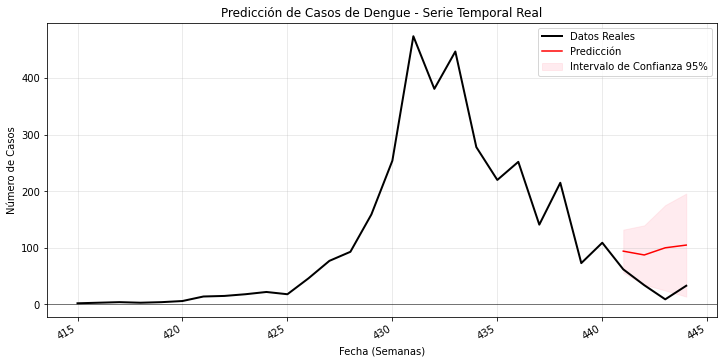

Error Absoluto Medio (MAE): 62.12 casos
Raíz del Error Cuadrático Medio (RMSE): 65.85 casos
Error Porcentual Absoluto Medio (MAPE): 359.67%


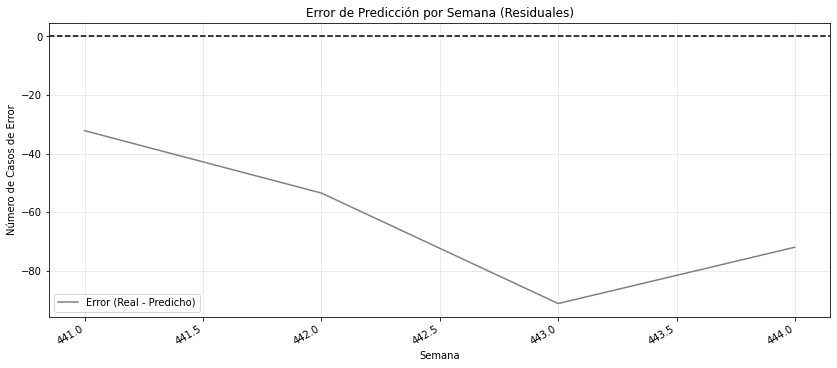

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                      exog=train_exog, 
                      order=(2, 1, 2), 
                      seasonal_order=(0, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast, exog=test_exog)
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Cienfuegos

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')


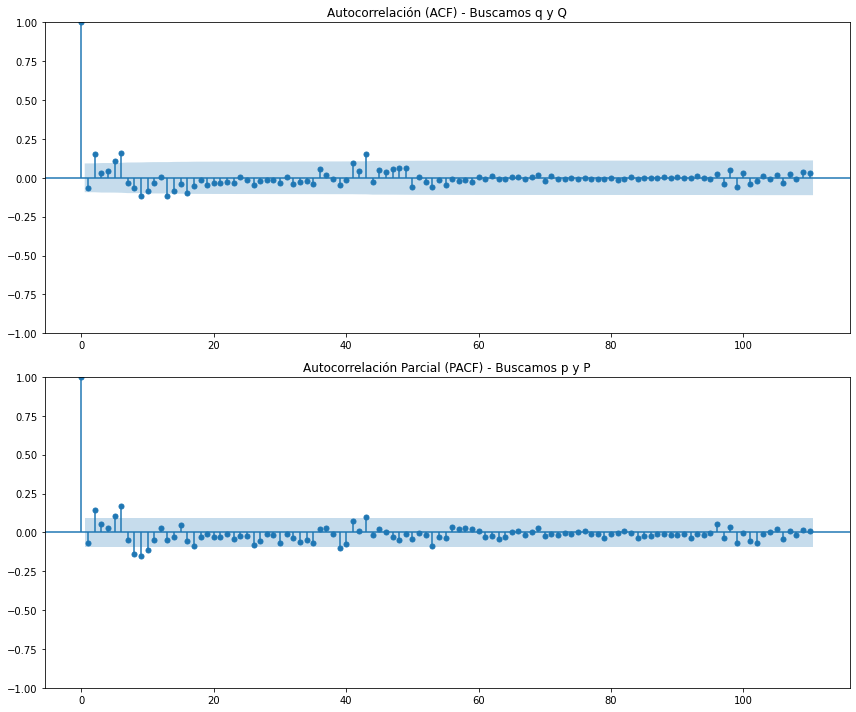

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Cienfuegos'

carpeta_salida = 'dataframes_provincias'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df_artemisa["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [31]:
import itertools
import statsmodels.api as sm

p =  [0,1,2,6]
q=[0,1,2,6]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]
exog_vars =df[["Temp_Med","Hum_Rel","Precip"]]

n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 5108.736955366446
(0, 1, 0) (0, 0, 1, 52) 3584.5262597126775
(0, 1, 0) (0, 1, 0, 52) 4598.40453469402
(0, 1, 0) (0, 1, 1, 52) 3361.017853707333
(0, 1, 0) (1, 0, 0, 52) 3592.640659343507
(0, 1, 0) (1, 0, 1, 52) 3586.339232641476
(0, 1, 0) (1, 1, 0, 52) 3371.833748211471
(0, 1, 0) (1, 1, 1, 52) 3309.027759693259
(0, 1, 1) (0, 0, 0, 52) 4911.3608797171655
(0, 1, 1) (0, 0, 1, 52) 3532.352129787429
(0, 1, 1) (0, 1, 0, 52) 4468.958083460217
(0, 1, 1) (0, 1, 1, 52) 3297.3847535981745
(0, 1, 1) (1, 0, 0, 52) 3548.5299968279314
(0, 1, 1) (1, 0, 1, 52) 3534.1930555143176
(0, 1, 1) (1, 1, 0, 52) 3316.887904394348


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(0, 1, 1) (1, 1, 1, 52) 3262.4598906402553
(0, 1, 2) (0, 0, 0, 52) 4893.691692166105
(0, 1, 2) (0, 0, 1, 52) 3517.776683088091
(0, 1, 2) (0, 1, 0, 52) 4445.751487291164
(0, 1, 2) (0, 1, 1, 52) 3277.8733491604817
(0, 1, 2) (1, 0, 0, 52) 3542.7110917117557
(0, 1, 2) (1, 0, 1, 52) 3519.6909817788664


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(0, 1, 2) (1, 1, 0, 52) 3306.59993433847


...

(6, 1, 6) (1, 0, 1, 52) 3470.622876186209


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(6, 1, 6) (1, 1, 0, 52) 3233.005923995188


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(6, 1, 6) (1, 1, 1, 52) 3151.108279946409
Mejor SARIMA: ((0, 1, 6), (1, 1, 1, 52)) con AIC: 3113.823742600576


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


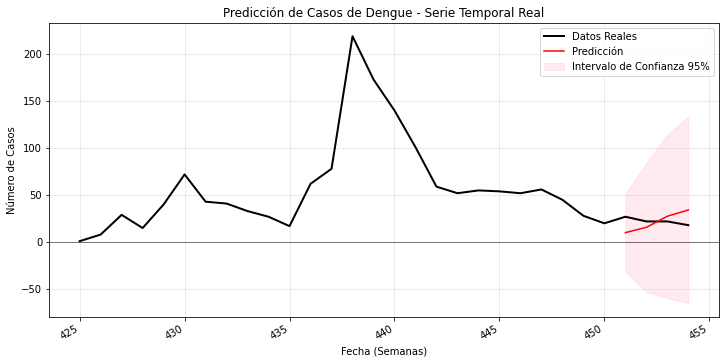

Error Absoluto Medio (MAE): 11.23 casos
Raíz del Error Cuadrático Medio (RMSE): 12.44 casos
Error Porcentual Absoluto Medio (MAPE): 51.59%


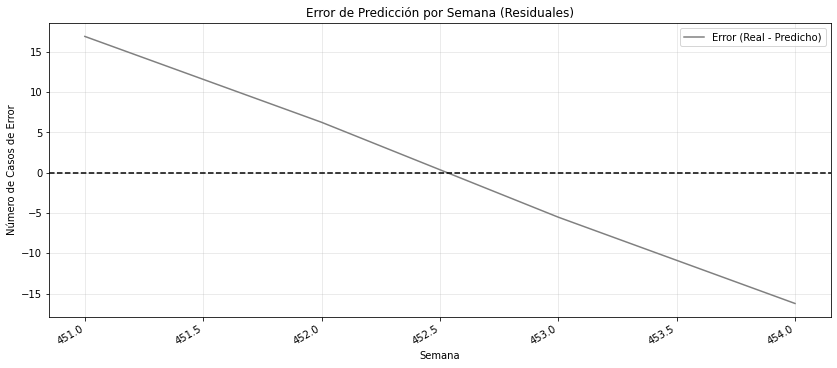

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                      exog=train_exog, 
                      order=(2, 1, 1), 
                      seasonal_order=(1, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast, exog=test_exog)
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Villa Clara

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue',
       'Temperatura med', 'Humedad Relat', 'Precipitaciones', 'Año_y', 'Mes',
       'Temperatura med_lag6'],
      dtype='object')


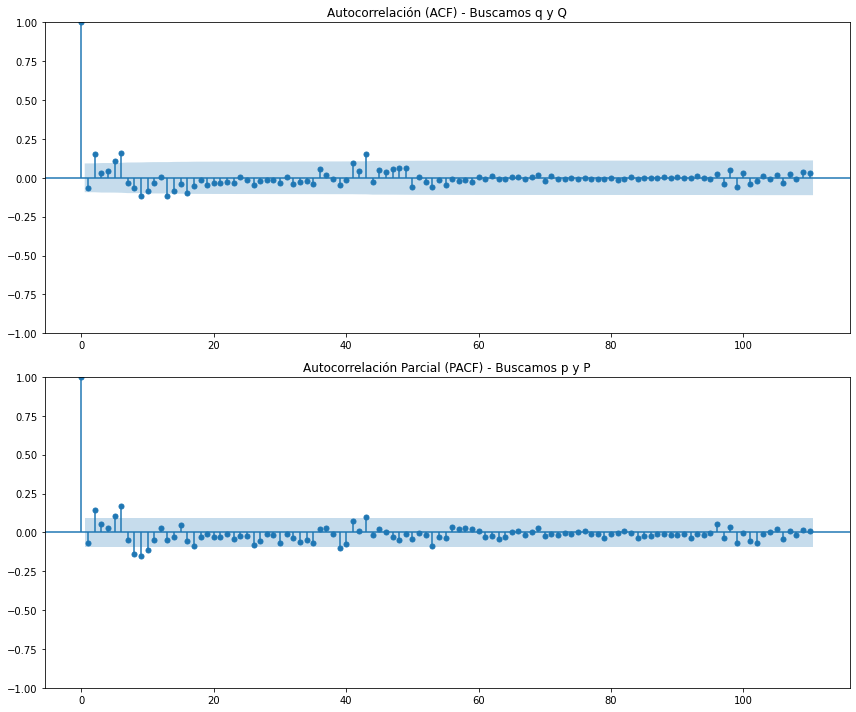

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Villa_Clara'

carpeta_salida = 'dataframes_con_lags'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df_artemisa["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [35]:
import itertools
import statsmodels.api as sm

p =  [0,1,2,6]
q=[0,1,2,6]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]
exog_vars =df[['Temperatura med', 'Humedad Relat', 'Precipitaciones','Temperatura med_lag6']]

n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 4921.745892221162
(0, 1, 0) (0, 0, 1, 52) 4084.355206453222
(0, 1, 0) (0, 1, 0, 52) 4463.379769484651
(0, 1, 0) (1, 0, 0, 52) 4093.20687365048
(0, 1, 0) (1, 0, 1, 52) 4085.231035752254
(0, 1, 0) (1, 1, 0, 52) 3711.708554535375
(0, 1, 0) (1, 1, 1, 52) 3674.9618865250513
(0, 1, 1) (0, 0, 0, 52) 4862.835580592191
(0, 1, 1) (0, 0, 1, 52) 4072.3530940795863
(0, 1, 1) (0, 1, 0, 52) 4433.786846818305
(0, 1, 1) (0, 1, 1, 52) 3689.990094131859
(0, 1, 1) (1, 0, 0, 52) 4091.0617373134537
(0, 1, 1) (1, 0, 1, 52) 4073.535274190156
(0, 1, 1) (1, 1, 0, 52) 3712.0397714197097


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(0, 1, 1) (1, 1, 1, 52) 3662.9244008844703
(0, 1, 2) (0, 0, 0, 52) 4837.8767811162015
(0, 1, 2) (0, 0, 1, 52) 4064.5254317944145
(0, 1, 2) (0, 1, 0, 52) 4414.8561502047
(0, 1, 2) (0, 1, 1, 52) 3680.0132265057764
(0, 1, 2) (1, 0, 0, 52) 4092.6648605941646


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(0, 1, 2) (1, 0, 1, 52) 4065.847343924621
(0, 1, 2) (1, 1, 0, 52) 3711.8408776849906


...

(6, 1, 6) (1, 0, 1, 52) 4030.9714677783513


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(6, 1, 6) (1, 1, 0, 52) 3639.1385947530043


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(6, 1, 6) (1, 1, 1, 52) 3625.4939904088515
Mejor SARIMA: ((2, 1, 6), (1, 1, 1, 52)) con AIC: 3597.269628942194


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


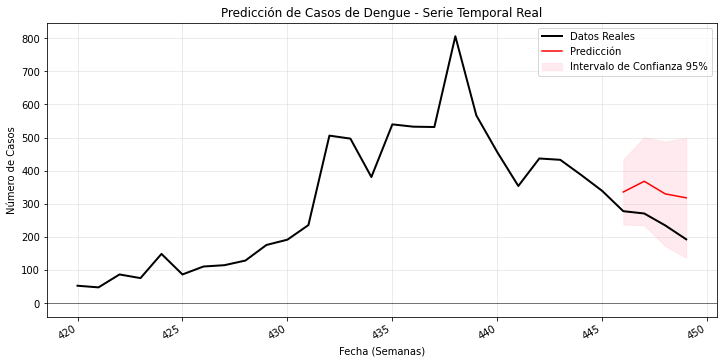

Error Absoluto Medio (MAE): 93.90 casos
Raíz del Error Cuadrático Medio (RMSE): 96.91 casos
Error Porcentual Absoluto Medio (MAPE): 40.53%


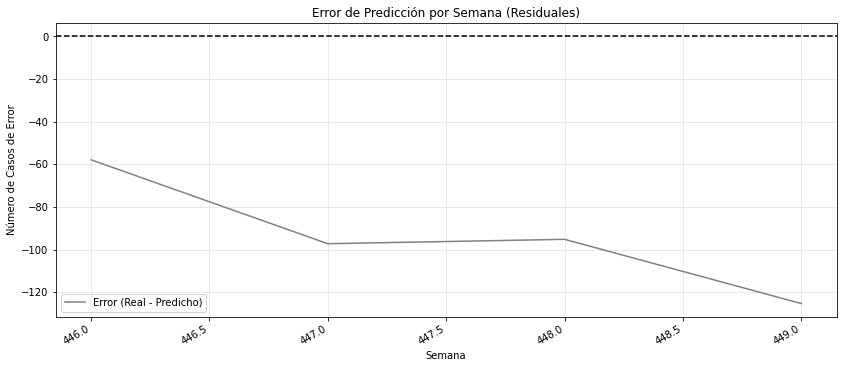

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                      exog=train_exog, 
                      order=(1, 1, 2), 
                      seasonal_order=(1, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast, exog=test_exog)
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Santi Spiritus

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')


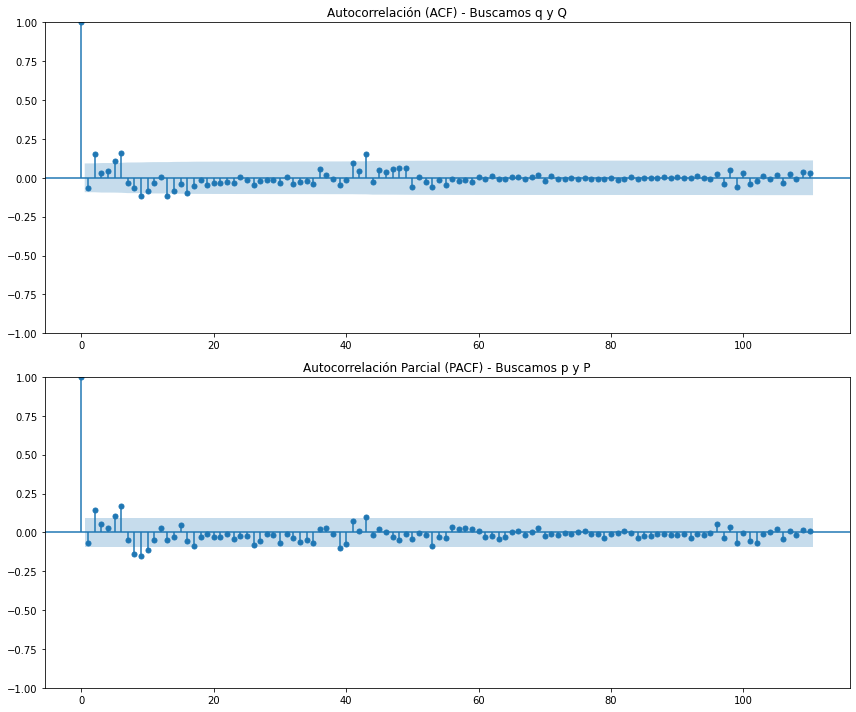

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Sancti_Spíritus'

carpeta_salida = 'dataframes_provincias'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df_artemisa["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [41]:
import itertools
import statsmodels.api as sm

p =  [0,1,2]
q=[0,1,2]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]
exog_vars =df[["Temp_Med","Hum_Rel","Precip"]]

n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 4714.477675159833
(0, 1, 0) (0, 0, 1, 52) 3879.625066952657
(0, 1, 0) (0, 1, 0, 52) 4270.424179344391
(0, 1, 0) (0, 1, 1, 52) 3491.2725677656445
(0, 1, 0) (1, 0, 0, 52) 3888.7821424425406
(0, 1, 0) (1, 0, 1, 52) 3881.5327115498685
(0, 1, 0) (1, 1, 0, 52) 3499.046650205618
(0, 1, 0) (1, 1, 1, 52) 3469.777564909973
(0, 1, 1) (0, 0, 0, 52) 4642.188111416674
(0, 1, 1) (0, 0, 1, 52) 3866.9476099237418
(0, 1, 1) (0, 1, 0, 52) 4219.260565189511
(0, 1, 1) (0, 1, 1, 52) 3479.906727192274
(0, 1, 1) (1, 0, 0, 52) 3884.9003373497153
(0, 1, 1) (1, 0, 1, 52) 3868.8796292797037
(0, 1, 1) (1, 1, 0, 52) 3496.7690361447612
(0, 1, 1) (1, 1, 1, 52) 3457.9813897070335
(0, 1, 2) (0, 0, 0, 52) 4633.692650690613
(0, 1, 2) (0, 0, 1, 52) 3859.9905052298755
(0, 1, 2) (0, 1, 0, 52) 4210.878119159481
(0, 1, 2) (0, 1, 1, 52) 3472.449711993787
(0, 1, 2) (1, 0, 0, 52) 3886.659524107283
(0, 1, 2) (1, 0, 1, 52) 3861.9193291057836
(0, 1, 2) (1, 1, 0, 52) 3498.347103375606
(0, 1, 2) (1, 1, 1, 52) 

/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(1, 1, 1) (1, 1, 1, 52) 3462.8962244967656
(1, 1, 2) (0, 0, 0, 52) 4635.005116017144
(1, 1, 2) (0, 0, 1, 52) 3861.968764957088


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(1, 1, 2) (0, 1, 0, 52) 4212.36627012207
(1, 1, 2) (0, 1, 1, 52) 3474.449375643521


...

(2, 1, 2) (1, 0, 1, 52) 3869.411190838019


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (1, 1, 0, 52) 3481.3259725395355


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (1, 1, 1, 52) 3455.1779670226283
Mejor SARIMA: ((0, 1, 2), (1, 1, 1, 52)) con AIC: 3450.5412831189815


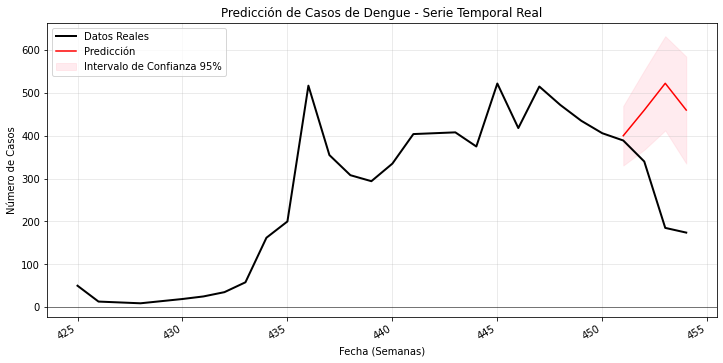

Error Absoluto Medio (MAE): 188.63 casos
Raíz del Error Cuadrático Medio (RMSE): 229.24 casos
Error Porcentual Absoluto Medio (MAPE): 96.23%


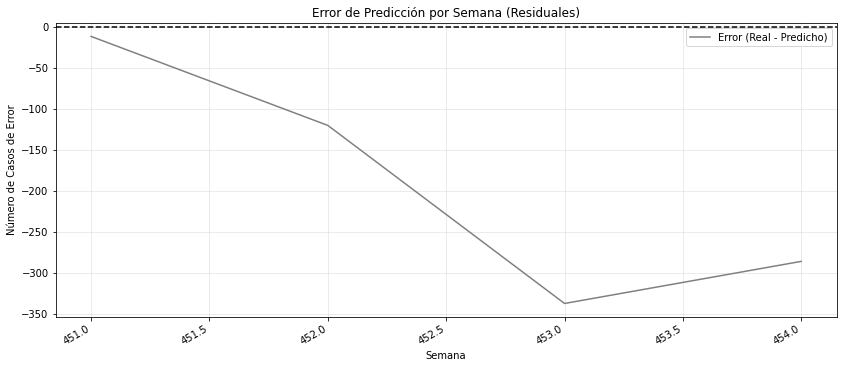

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                      exog=train_exog, 
                      order=(0, 1, 2), 
                      seasonal_order=(1, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast, exog=test_exog)
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Ciego de Avila

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Ciego_de_Ávila'

carpeta_salida = 'dataframes_provincias'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df_artemisa["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [ ]:
import itertools
import statsmodels.api as sm

p =  [0,1,2]
q=[0,1,2]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]
exog_vars =df[["Temp_Med","Hum_Rel","Precip"]]

n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                      exog=train_exog, 
                      order=(2, 1, 1), 
                      seasonal_order=(1, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast, exog=test_exog)
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Camaguey

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Camagüey.csv'

carpeta_salida = 'dataframes_con_lags'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df_artemisa["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [ ]:
import itertools
import statsmodels.api as sm

p =  [0,1,2]
q=[0,1,2]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]
exog_vars =df[["Temp_Med","Hum_Rel","Precip"]]

n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                      exog=train_exog, 
                      order=(2, 1, 1), 
                      seasonal_order=(1, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast, exog=test_exog)
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Las Tunas

# Granma

# Holguin 

# Santiago de Cuba 

# Guantanamo 

# Isla de la Juventud 